In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import networkx as nx
import pandas as pd
from scipy.optimize import fsolve

# physical review E column width in inches
col_width = 3+3/8
plt.style.use("style.mplstyle") # closer to LaTeX

# summary data
from Load_MD_Data import *

In [2]:
# Degree Distribution from Arrhenius fit - As obtained in DegreeDistributionAnalysis.ipynb
# Arrhenius parameters
Ahh,Chh = 4.4056,  18704
A3,C3   = 6.46e-4, 30526
# functions for p3/phh
def phh_from_fit(HCR,Temp):
    """
    Estimate the parameter phh as a function of the hydrogen/carbon ratio (HCR) and temperature (Temp) using
    the equilibrium constant (Khh). 
    """
    K = Ahh*np.exp(-Chh/Temp)
    return 1 - (4/HCR + 1 - np.sqrt((4/HCR-1)**2+16*K/HCR))/2/(1-K)
def p3_from_fit(HCR,Temp):
    """
    Estimate the parameter \bar{p}_3 as a function of the hydrogen/carbon ratio (HCR) and temperature (Temp) using
    the equilibrium constant (Kc=c). 
    """
    K = A3*np.exp(-C3/Temp)
    phh = phh_from_fit(HCR,Temp)
    aux = (12.011+HCR)*Temp
    return K*aux/(HCR*phh + K*aux)

# Arrhenius fits for loop reaction rates
We start by fitting the effective equilibrium constants $K_{\ell}^\text{eff}$, $\ell=3,4,...,8$ and $K_L^\text{eff}$ for loop formation described in Appendix D. To summarize these reactions are:

* Triangles: a double bond re-arranging to close a path of length 3
  $$K_3^{\rm eff} = A_3e^{-C_3/{\rm Temp}} = {\lambda\phi_3}/{\bar{p}_3}$$
* Squares (Pentagons): a path of length 4 (5) with two double bonds that close into a loop with a double bond
  $$K_4^{\rm eff} = A_4e^{-C_4/{\rm Temp}} = \lambda\phi_4/(\bar{p}_3)^2$$
  $$K_5^{\rm eff} = A_5e^{-C_5/{\rm Temp}} = \lambda\phi_5/(\bar{p}_3)^2$$
* Ring Expansion: an atom collides with a ring losing two of its bonds to re-construct the ring with an extra atom. Assumed an atom loses C-H bonds, use $r_{\rm HCH}$ to count the rate of H-C-H triples per carbon that can collide with a ring.
  $$K_{\ell}^{\rm eff} = A_{\ell}e^{-C_{\ell}/{\rm Temp}} = \frac{\phi_\ell}{\phi_{\ell-1}} \frac{N_{\rm H} p_{\rm HH}}{N_{\rm C} r_{\rm HCH}}$$
  $$r_{\rm HCH} = \sum_{k_{\rm C},k_{\rm H}}\binom{k_{\rm H}}{2}\bar{p}_{k_{\rm C},k_{\rm H}}$$
* Tail Ring Expansion: $K_L^{\rm eff}$ where the ratio $\phi_\ell/\phi_{\ell-1}$ in the previous reactions converge to a constant. Here the cutoff is chosen to be 9.

In [3]:
# geometric tail rate decay
def tail_rate(x):
    start,end = 8,15
    xdata = np.arange(start,end+1)
    ydata = x[xdata]
    A = np.vstack([xdata, np.ones_like(xdata)]).T
    m, b = np.linalg.lstsq(A, np.log(ydata), rcond=None)[0]
    return np.exp(m)

C:\Users\HP\AppData\Local\Temp\ipykernel_35912\3574858940.py:7: RuntimeWarning: divide by zero encountered in log
  m, b = np.linalg.lstsq(A, np.log(ydata), rcond=None)[0]


A coefficients: [0.12389968644450339, 0.00015152477934345335, 6.773381548304006e-05, 4.832975625091125, 5.219656238710266, 4.431445994369334, 4.420962216144649]
C coefficients: [5451.064396640944, -28110.146346270267, -36237.86724516978, 18948.7925434652, 22167.948054855005, 20251.10975570232, 18253.555510771366]


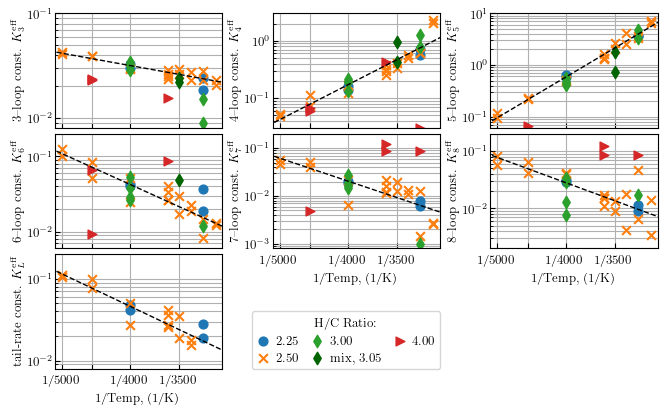

In [4]:
# pre-format figure
fig,ax = plt.subplots(3,3,figsize=(2*col_width,1.25*col_width))
ax[-1,1].set_axis_off()
ax[-1,-1].set_axis_off()
msize=40

# initializations
Temp = global_data['Temp']
HCR = global_data['Nh']/global_data['Nc']
Nc = global_data['Nc']

# measured params
p3 = global_data['CDegDist'].apply(lambda x: x[3]/(x[3]+x[4]))
phh = 2*global_data['Nhh']/(2*global_data['Nhh']+global_data['Nch'])
pch = global_data['Nch']/(2*global_data['Ncc']+global_data['Nch'])

rHCH = 3*pch*pch*(2-p3)
r_tail = skeleton_data['LoopSizeDist'].apply(tail_rate) # this will throw a warning as hydrogen rich systems have some 0 values

Vc = (12 + HCR)*Temp

A_vec = []
C_vec = []

phi3 = skeleton_data['LoopSizeDist'].apply(lambda x: x[3]).apply(lambda x: max(x,1e-14))
for L in range(3,10):
    row,col = (L-3)//3,(L-3)%3
    # if row == 2: col = 1

    phiL = skeleton_data['LoopSizeDist'].apply(lambda x: x[L]).apply(lambda x: max(x,1e-14))
    phiLm = skeleton_data['LoopSizeDist'].apply(lambda x: x[L-1]).apply(lambda x: max(x,1e-14))
    Lam = skeleton_data['LoopCountDist'].apply(lambda x: x@np.arange(len(x)))/Nc

    # effective reaction rates
    if L == 3:
        Data = Lam*phiL / p3                    # splitting double bond
    elif L == 4 or L == 5:
        Data = Lam*phiL / p3 / p3               # triangle + double bonds
    elif L < 9:
        Data = (phh*HCR*phiL) / (rHCH*phiLm)    # adding a HCH triple to increase loop size
    else:
        Data = r_tail * HCR*phh / rHCH          # geometric tail law

    ### training data C4H10, ignore 3200K & 3300K for tail rate, very noisy with divide by zero errors
    train_idx = HCR==2.5
    if L > 8: train_idx *= Temp>3300
    xdata = 1/Temp[train_idx].to_numpy(dtype=float)
    ydata = np.log(Data[train_idx].to_numpy(dtype=float))

    ### least squares to get Arrhenius fit
    M = np.vstack([xdata, np.ones(len(xdata))]).T
    Cm, logA = np.linalg.lstsq(M, ydata, rcond=None)[0]
    A = np.exp(logA)
    C = -Cm
    A_vec.append(A)
    C_vec.append(C)

    # plot colored by HCR
    ax[row,col].plot([1/5100,1/3100],[A*np.exp(-C/5100),A*np.exp(-C/3100)],'k--',lw=1) # arrh. fit
    h_vec = list(range(6))
    for i,aux in enumerate([(2.25,'o','C0'),(2.5,'x','C1'),(3,'d','C2'),(3.05,'d','darkgreen'),(4,'>','C3')]):
        hcr,marker,color = aux[0],aux[1],aux[2]
        idx = HCR==hcr
        h_vec[i] = ax[row,col].scatter(1/Temp[idx],Data[idx],c=color,s=msize,alpha=1,marker=marker)

    
    ax[row,col].set_xticks(ticks=[1/3000,1/3500,1/4000,1/4500,1/5000],
                               labels=["1/3000","1/3500","1/4000","","1/5000"])
    ax[row,col].set_xlim([1/5000-5e-6,1/3200+5e-6])
    if row == 2 or (row == 1 and col>0):   ax[row,col].set_xlabel('1/Temp, (1/K)')
    else:                                  ax[row,col].set_xticklabels([])
    ax[row,col].tick_params(axis='y',pad=1)

    # format
    ax[row,col].set_yscale('log')
    # good y-limits that are fit dependent
    if L==3: ax[row,col].set_ylim([8e-3,1e-1])
    elif L==4: ax[row,col].set_ylim([3e-2,3e0])
    elif L==5: ax[row,col].set_ylim([6e-2,1e1])
    elif L==6: ax[row,col].set_ylim([6e-3,2e-1])
    elif L==7: ax[row,col].set_ylim([8e-4,2e-1])
    elif L==8: ax[row,col].set_ylim([2e-3,2e-1])
    else: ax[row,col].set_ylim([8e-3,2e-1])
    ax[row,col].grid(which='both')
    # ylabel
    if L < 9:   ax[row,col].set_ylabel(rf'{L}--loop const. $K_{{{L:.0f}}}^{{\rm eff}}$',labelpad=3)
    else:       ax[row,col].set_ylabel(r'tail-rate const. $K_L^\text{eff}$',labelpad=3)

ax[-1,1].legend(handles=h_vec,labels=['2.25','2.50','3.00','mix, 3.05','4.00'],ncols=3,title='H/C Ratio:',
                   columnspacing=1,handletextpad=0.5,handlelength=1,loc='lower right',borderaxespad=0)
plt.tight_layout() 
plt.subplots_adjust(hspace=0.05,wspace=0.3)
plt.savefig('../../figures/Loops/AllArrhFits.pdf')

# Equilibrium constants for a given loop length ell and Temperature (T).
# if ell>=9 uses the tail equilibrium constant KL instead of Kell.
def Keff(ell,T):
    return A_vec[min(ell-3,9-3)]*np.exp(-C_vec[min(ell-3,9-3)]/T)

# print coefficients
print('A coefficients:',A_vec)
print('C coefficients:',C_vec)

# Error analysis of loop rates
- Cell 1: comparison of the loop rate distribution of the proposed model compared to MD data for each set of initial conditions. Unused in the paper, but a good reference. These are saved to `Figures/Loops/ReaxResults`. This cell also computes the Wasserstein W1 distance between these two distributions to be visualized in the next cell.
- Cell 2: summary comparison of the loop rate distribution from the proposed model compared to MD data. Contains (a) two sample loop length distributions compared to their Arrhenius fits, (b) Wasserstein distance of the loop length distribution from MD data vs. Arrhenius fits, and (c) comparison of the loop rate per C atom $\lambda$ from MD vs. Arrhenius fits.

In [5]:
Lam_exp = []
Lam_arrh = []

W1_vec = []
HCR  = global_data_avg['Nh']/global_data_avg['Nc']
Nc   = global_data_avg['Nc']
Temp = global_data_avg['Temp']
Lam  = skeleton_data_avg['LoopCountDist'].apply(lambda x: x@np.arange(len(x)))/Nc

for idx in global_data_avg.index:
    hcr, T = HCR.loc[idx], Temp.loc[idx]
    p3, phh = p3_from_fit(hcr,T), phh_from_fit(hcr,T)
    lam = Lam.loc[idx]
    # measured distribution
    LamPhi_dist_exp = lam*skeleton_data_avg['LoopSizeDist'].loc[idx]
    Lam_exp.append(sum(LamPhi_dist_exp))
    Measured = LamPhi_dist_exp[:-1]/sum(LamPhi_dist_exp[:-1]) # normalize

    Vc = (12+hcr)*T
    kc = 4-p3
    pch = hcr/kc * (1-phh)
    pcc = 1-pch

    rHCH = 3*(2-p3)*pch**2

    # approximate distribution
    LamPhi_dist_arrh = np.zeros_like(Measured)
    LamPhi_dist_arrh[3] = Keff(3,T) * p3
    LamPhi_dist_arrh[4] = Keff(4,T) * p3**2 
    LamPhi_dist_arrh[5] = Keff(5,T) * p3**2 
    for L in range(6,len(LamPhi_dist_arrh)):
        LamPhi_dist_arrh[L] = Keff(L,T) * LamPhi_dist_arrh[L-1]*rHCH / (phh*hcr)
    Lam_arrh.append(sum(LamPhi_dist_arrh))
    Arrhenius = LamPhi_dist_arrh/sum(LamPhi_dist_arrh) # normalize
    
    fig, ax = plt.subplots(1,2,figsize=(12,6))
    ax[0].plot(Measured)
    ax[0].plot(Arrhenius)
    ax[0].set_xlabel('Loop length '+r'$\ell$')
    ax[0].set_yscale('log')
    ax[0].set_title('log scale')
    ax[0].set_ylabel('Fraction of loops of length '+r'$\ell,\ \phi_\ell$')
    ax[1].plot(Measured)
    ax[1].plot(Arrhenius)
    ax[1].set_xlabel('Loop length '+r'$\ell$')
    ax[1].legend(['MD Data','Arrhenius fit'])
    ax[0].grid()
    
    fig.suptitle(idx)
    plt.tight_layout()
    plt.savefig('../../Figures/Loops/ReaxResults/' + idx + '_LoopDist_fit.pdf')
    # plt.show() # too many
    plt.close()

    # compute Wasserstein - used in second cell
    W1_vec.append(sum(abs(np.cumsum(Measured-Arrhenius))))

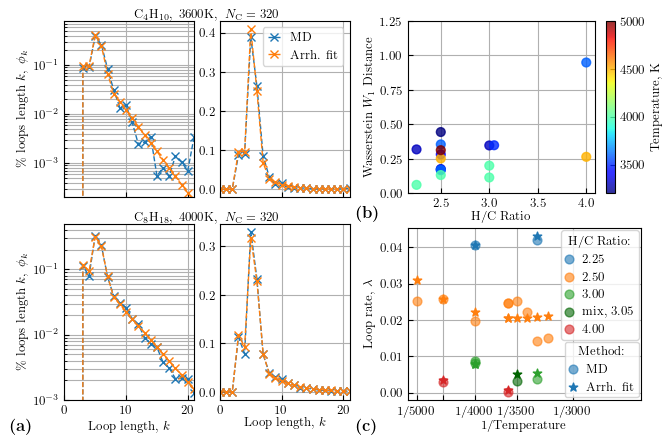

In [7]:
fig= plt.figure(figsize=(2*col_width,4/3*col_width))
gs = mpl.gridspec.GridSpec(1,2,figure=fig,width_ratios=[.55,.45])

msize = 40
width = 1

gs_0 = mpl.gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs[0],hspace=.15,wspace=.2)
gs_1 = mpl.gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[1])

ax =[[0,0],[0,0]]
tit_ax = [0,0]

for r,item in enumerate([('C4H10_3600K_1120at',r'${\rm C}_4{\rm H}_{10},\ 3600{\rm K},\ N_{\rm C}=320$'),
                        ('C8H18_4000K_1040at',r'${\rm C}_8{\rm H}_{18},\ 4000{\rm K},\ N_{\rm C}=320$')]):
    idx,label = item
    hcr, T = HCR.loc[idx], Temp.loc[idx]
    p3, phh = p3_from_fit(hcr,T), phh_from_fit(hcr,T)
    lam = Lam.loc[idx]
    # measured distribution
    LamPhi_dist_exp = lam*skeleton_data_avg['LoopSizeDist'].loc[idx]
    Measured = LamPhi_dist_exp[:-1]/sum(LamPhi_dist_exp[:-1]) # normalize

    Vc = (12+hcr)*T
    kc = 4-p3
    pch = hcr/kc * (1-phh)
    pcc = 1-pch
    rHCH = 3*(2-p3)*pch**2

    # approximate distribution
    LamPhi_dist_arrh = np.zeros_like(Measured)
    LamPhi_dist_arrh[3] = Keff(3,T) * p3
    LamPhi_dist_arrh[4] = Keff(4,T) * p3**2 
    LamPhi_dist_arrh[5] = Keff(5,T) * p3**2 
    for L in range(6,len(LamPhi_dist_arrh)):
        LamPhi_dist_arrh[L] = Keff(L,T) * LamPhi_dist_arrh[L-1]*rHCH / (phh*hcr)
    Arrhenius = LamPhi_dist_arrh/sum(LamPhi_dist_arrh) # normalize

    ax[r][0] = fig.add_subplot(gs_0[r,0])
    ax[r][0].plot(Measured,'x--',lw=width)
    ax[r][0].plot(Arrhenius,'x--',lw=width)
    ax[r][0].grid(which='both')
    if r: ax[r][0].set_xlabel(r'Loop length, $k$')
    ax[r][0].set_ylabel(r'\% loops length $k,\ \phi_k$')
    ax[r][0].set_yscale('log')

    
    ax[r][1] = fig.add_subplot(gs_0[r,1])
    ax[r][1].plot(Measured,'x--',lw=width)
    ax[r][1].plot(Arrhenius,'x--',lw=width)
    if r: ax[r][1].set_xlabel(r'Loop length, $k$',labelpad=1)
    ax[r][1].grid(which='both')
    ax[r][0].set_xlim([0,21])
    ax[r][1].set_xlim([0,21])

    tit_ax[r] = fig.add_subplot(gs_0[r,:])
    tit_ax[r].axis('off')
    tit_ax[r].set_title(label,fontsize=9,pad=2)
ax[0][0].set_ylim([2e-4,8e-1])
ax[0][1].legend(['MD','Arrh. fit'],loc='upper right',handlelength=1)
ax[1][0].set_ylim([1e-3,5e-1])
ax[0][0].set_xticklabels([])
ax[0][1].set_xticklabels([])


# Wasserstein distance
ax_Wass = fig.add_subplot(gs_1[0])
pw = ax_Wass.scatter(HCR,W1_vec,c=global_data_avg['Temp'],cmap='jet',alpha=.8,s=msize)
ax_Wass.set_ylabel('Wasserstein '+r'$W_1$'+' Distance')
ax_Wass.set_xlabel('H/C Ratio',labelpad=1)
plt.colorbar(pw,label='Temperature, K',ax=ax_Wass)
ax_Wass.set_ylim([0,1.25])
ax_Wass.grid()

# comparison of loop rates
ax_loopr = fig.add_subplot(gs_1[1])
h = []
for i,hcr in enumerate([2.25,2.5,3,3.05,4]):
    idx = np.abs(HCR-hcr)<.01
    color = 'C'+str(i)
    if hcr == 3.05: color = 'darkgreen'
    if hcr == 4: color = 'C3'
    # print(Nc[idx])
    h.append(ax_loopr.scatter(1/Temp[idx],np.array(Lam_exp)[idx],marker='o',c=color,alpha=.6,s=msize))
    hx = ax_loopr.scatter(1/Temp[idx],np.array(Lam_arrh)[idx],marker='*',c=color,s=msize)
    if i == 0: hMD = hx
ax_loopr.set_xticks(ticks=[1/3000,1/3500,1/4000,1/4500,1/5000],labels=["1/3000","1/3500","1/4000","","1/5000"])
ax_loopr.set_xlabel('1/Temperature',labelpad=1)
ax_loopr.set_ylabel(r'Loop rate, $\lambda$')
b = ax_loopr.scatter([],[],marker='None')
# h[0],h[5],h[6] = b,b,h[1]
ax_loopr.set_xlim([1/5200,1/2550])
legend1 = ax_loopr.legend(handles=h,\
            labels=['2.25','2.50','3.00','mix, 3.05','4.00'],title='H/C Ratio:',
            ncol=1,handlelength=1/2,loc='upper right',borderaxespad=.2)
ax_loopr.add_artist(legend1)
ax_loopr.legend([h[0],hMD],['MD','Arrh. fit'],title='Method:',handlelength=1/2,loc='lower right',borderaxespad=.2)
ax_loopr.grid()

plt.tight_layout()

ax[1][1].text(-34,-.08,r'\textbf{(a)}',fontsize=12)
ax[1][1].text(22,.36,r'\textbf{(b)}',fontsize=12)
ax[1][1].text(22,-.08,r'\textbf{(c)}',fontsize=12)
plt.savefig('../../Figures/Loops/ReaxResults/W1Loop+Loopr+LoopDist.pdf')